# Custom surface atlas review — Schaefer2018N400n7

Exploratory only — no outputs committed (nbstripout). Reads the shared brainlink.db and
real CAT12 cohort output via bagpipe's config, no paths/data hardcoded here.

The production model trains on `Schaefer2018N400n7Tian2020S2` (400 cortical regions,
7-network, + Tian S2 subcortex). CAT12 only ships this as a **volume** atlas natively;
on the **surface** side it only ships the 17-network variant. Fixing that the way the
volume `ownatlas` field works (CAT12's own-atlas surface batch field,
`output.sROImenu.satlases.ownatlas`) was tried and confirmed **not to work** in this
CAT26 build — a real single-subject test showed the field has no effect at all
(`docs/cat12_container_spec.md` §4b has the full investigation).

Fixed instead in `bagpipe.app.surface_atlas.custom_surface_regional`: nearest-vertex
resampling from CAT12's own native thickness + spherical-registration output onto the
atlas grid, then per-region averaging — the same method CAT12's own surface-ROI code
uses internally, just run ourselves in Python. This notebook:

1. Reproduces the validation against CAT12's own DK40 output (this notebook's own run,
   not just the one-off check from the dev session).
2. Looks at the resulting Schaefer-7N regional values themselves — distribution,
   hemisphere symmetry, network-level structure, cross-atlas consistency, coverage.

## 0. Setup

In [13]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel.freesurfer.io as fio
import numpy as np
import pandas as pd
import seaborn as sns

from bagpipe.app.cat12_parse import parse_surface_regional
from bagpipe.app.surface_atlas import custom_surface_regional
from bagpipe.core.config import get_path
from bagpipe.db.ingest_cat12_cohort import cohort_dir_from_config

# repo root, regardless of the kernel's actual cwd (nbconvert/VS Code run
# notebooks from their own directory, not necessarily the repo root) — needed
# because config/cat12_cohort.yaml is referenced by a repo-relative path, not
# through bagpipe.core.config's get_path registry.
_root = Path.cwd()
while not (_root / "pyproject.toml").exists():
    _root = _root.parent
os.chdir(_root)

sns.set_theme(style="whitegrid")
con = sqlite3.connect(get_path("db_path"))
cohort_dir = cohort_dir_from_config()

## 1. Validate against CAT12's own DK40 output

Same resampling method, but with CAT12's *own* bundled DK40 `.annot` in place of the
custom Schaefer one — lets us check the result against CAT12's own ground truth
(`catROIs_*.xml`), since CAT12 computes DK40 natively. Picks the first real cohort
subject with both surface reconstruction and native ROI output — not a fixed subject ID,
so this still works as the cohort run keeps growing.

In [14]:
def _find_validation_subject(cohort_dir: Path) -> tuple[Path, Path, str]:
    """Returns (surf_dir, label_dir, cat12_name) for the first subject with both
    surface output and native catROIs_*.xml."""
    for sub_dir in sorted(cohort_dir.glob("sub-*")):
        for ses_dir in sorted(sub_dir.glob("ses-*")):
            surf_dir = ses_dir / "anat" / "surf"
            label_dir = ses_dir / "anat" / "label"
            lh_thickness = sorted(surf_dir.glob("lh.thickness.*")) if surf_dir.is_dir() else []
            catrois = sorted(label_dir.glob("catROIs_*.xml")) if label_dir.is_dir() else []
            if lh_thickness and catrois:
                name = lh_thickness[0].name.removeprefix("lh.thickness.")
                return surf_dir, label_dir, name
    raise RuntimeError("no cohort subject with both surface + catROIs output found yet")


surf_dir, label_dir, name = _find_validation_subject(cohort_dir)
print("validation subject:", surf_dir.parent.parent.name, "/", surf_dir.parent.parent.parent.name)

# CAT12's own bundled DK40/Destrieux annot ships inside the built image, not the repo —
# extract once via apptainer if not already cached locally (cheap, ~1MB, read-only).
dk40_annot_dir = Path(get_path("surface_atlas_lh_annot")).parent
lh_dk40 = dk40_annot_dir / "lh.aparc_DK40.freesurfer.annot"
rh_dk40 = dk40_annot_dir / "rh.aparc_DK40.freesurfer.annot"
if not (lh_dk40.exists() and rh_dk40.exists()):
    import subprocess
    image = str(get_path("cat12_apptainer_image"))
    toolbox = (
        "/opt/cat12_extract/cat_standalone/spm25_mcr/home/runner/work/cat12/cat12/"
        "spm/toolbox/CAT/atlases_surfaces"
    )
    for hemi, dest in (("lh", lh_dk40), ("rh", rh_dk40)):
        subprocess.run(
            ["apptainer", "exec", image, "cat", f"{toolbox}/{hemi}.aparc_DK40.freesurfer.annot"],
            stdout=dest.open("wb"), check=True,
        )
print("DK40 annot ready:", lh_dk40.exists(), rh_dk40.exists())

validation subject: ses-200109071247 / sub-200109071247
DK40 annot ready: True True


68 regions compared — max diff 0.0029mm, mean diff 0.0006mm (mean thickness 2.52mm)


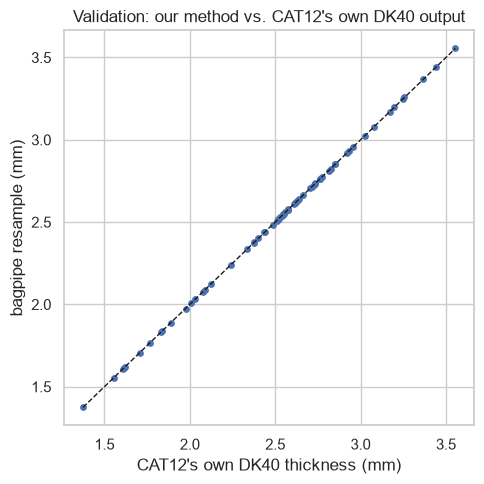

In [15]:
mine_dk40 = custom_surface_regional(
    surf_dir / f"lh.thickness.{name}", surf_dir / f"rh.thickness.{name}",
    surf_dir / f"lh.sphere.reg.{name}.gii", surf_dir / f"rh.sphere.reg.{name}.gii",
    lh_dk40, rh_dk40,
    get_path("surface_atlas_lh_ref_sphere"), get_path("surface_atlas_rh_ref_sphere"),
)
n = len(mine_dk40) // 2
mine_dk40 = pd.concat([
    mine_dk40.iloc[:n].assign(label=lambda d: "l" + d["label"]),
    mine_dk40.iloc[n:].assign(label=lambda d: "r" + d["label"]),
]).set_index("label")

cat_dk40 = parse_surface_regional(label_dir / f"catROIs_{name}.xml", "aparc_DK40").set_index("label")
cat_dk40 = cat_dk40[~cat_dk40.index.str.endswith(("unknown", "corpuscallosum"))]

cmp = mine_dk40.join(cat_dk40, lsuffix="_mine", rsuffix="_cat", how="inner")
cmp["abs_diff"] = (cmp["thickness_mine"] - cmp["thickness_cat"]).abs()
print(f"{len(cmp)} regions compared — max diff {cmp['abs_diff'].max():.4f}mm, "
      f"mean diff {cmp['abs_diff'].mean():.4f}mm (mean thickness {cmp['thickness_cat'].mean():.2f}mm)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(cmp["thickness_cat"], cmp["thickness_mine"], s=15)
lims = [cmp[["thickness_cat", "thickness_mine"]].min().min(), cmp[["thickness_cat", "thickness_mine"]].max().max()]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("CAT12's own DK40 thickness (mm)")
ax.set_ylabel("bagpipe resample (mm)")
ax.set_title("Validation: our method vs. CAT12's own DK40 output")
plt.tight_layout()

## 2. Coverage — how many sessions have the custom atlas so far

In [16]:
surf_counts = pd.read_sql('''
    select atlas, metric, count(distinct subject_key || "_" || session_id) as n_sessions
    from features where atlas like "surf_%" group by atlas, metric
''', con)
print(surf_counts)

schaefer = pd.read_sql('''
    select subject_key, session_id, region, value
    from features where atlas = "surf_Schaefer2018N400n7" and metric = "thickness"
''', con)
print(f"\n{schaefer['session_id'].nunique()} sessions, {len(schaefer)} rows "
      f"({len(schaefer) / max(schaefer['session_id'].nunique(), 1):.0f} regions/session expected 400)")


                     atlas             metric  n_sessions
0                surf_DK40          thickness         367
1           surf_Destrieux          thickness         367
2  surf_Schaefer2018N400n7               area         162
3  surf_Schaefer2018N400n7  fractal_dimension         162
4  surf_Schaefer2018N400n7       gyrification         162
5  surf_Schaefer2018N400n7       sulcal_depth         162
6  surf_Schaefer2018N400n7          thickness         368

368 sessions, 147200 rows (400 regions/session expected 400)


## 3. Regional thickness distribution

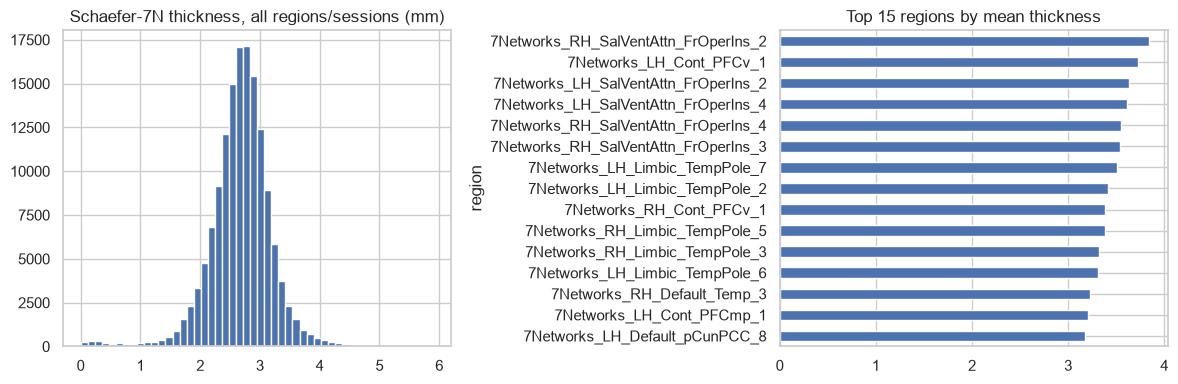

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
schaefer["value"].hist(bins=50, ax=axes[0])
axes[0].set_title("Schaefer-7N thickness, all regions/sessions (mm)")

region_means = schaefer.groupby("region")["value"].mean().sort_values(ascending=False)
region_means.head(15).plot.barh(ax=axes[1])
axes[1].set_title("Top 15 regions by mean thickness")
axes[1].invert_yaxis()
plt.tight_layout()

## 4. Hemisphere symmetry

Schaefer region names already encode hemisphere (`7Networks_LH_...`/`7Networks_RH_...`)
— homologous LH/RH region pairs should correlate strongly; real asymmetry exists but
should be small relative to between-region variation.

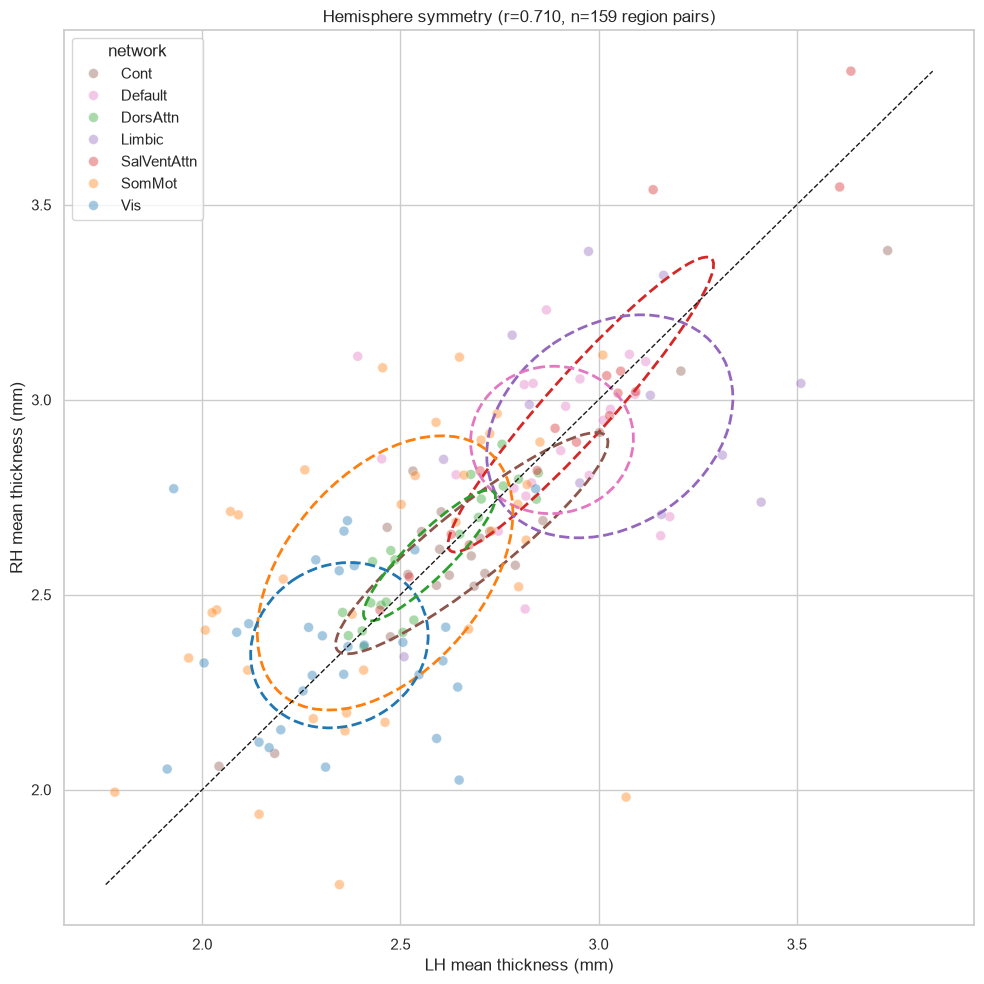

In [6]:
networks = ["SalVentAttn", "Cont", "Limbic", "Default", "SomMot", "Vis", "DorsAttn"]
networks_to_colors = {
    "SalVentAttn": "tab:red",
    "Cont": "tab:brown",
    "Limbic": "tab:purple",
    "Default": "tab:pink",
    "SomMot": "tab:orange",
    "Vis": "tab:blue",
    "DorsAttn": "tab:green",
}
region_means_df = region_means.rename("thickness").reset_index()
region_means_df["hemi"] = region_means_df["region"].str.extract(r"7Networks_(LH|RH)_")
region_means_df["homolog"] = region_means_df["region"].str.replace("_LH_", "_", regex=False).str.replace("_RH_", "_", regex=False)
# search for any of the networks in networks in the region name
region_means_df["network"] = region_means_df["region"].apply(lambda r: next((n for n in networks if n in r), "Unknown"))
region_to_network = region_means_df.set_index("region")["network"].to_dict()

wide = region_means_df.pivot(index="homolog", columns="hemi", values="thickness").dropna()
wide["network"] = wide.index.map(lambda r: next((n for n in networks if n in r), "Unknown"))
corr = wide["LH"].corr(wide["RH"])
fig, ax = plt.subplots(figsize=(10, 10))

sns.scatterplot(
    data=wide.reset_index(),
    x="LH", y="RH", hue="network",
    s=50, ax=ax, legend=True, alpha=0.4,
    palette=networks_to_colors
)

# add circles to group by network
for network in networks:
    subset = wide[wide["network"] == network]
    if len(subset) < 2:
        continue
    x = subset["LH"]
    y = subset["RH"]
    # calculate the mean and std for the ellipse
    mean_x, mean_y = x.mean(), y.mean()
    cov = np.cov(x, y)
    # eigenvalues and eigenvectors
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * np.sqrt(vals)
    ellipse = plt.matplotlib.patches.Ellipse(
        (mean_x, mean_y), width, height, angle=theta,
        edgecolor=networks_to_colors[network], facecolor='none', lw=2, ls='--'
    )
    ax.add_patch(ellipse)

lims = [wide.drop(columns=["network"]).min().min(), wide.drop(columns=["network"]).max().max()]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("LH mean thickness (mm)")
ax.set_ylabel("RH mean thickness (mm)")
ax.set_title(f"Hemisphere symmetry (r={corr:.3f}, n={len(wide)} region pairs)")
plt.tight_layout()

## 5. Network-level structure (Yeo 7-network grouping)

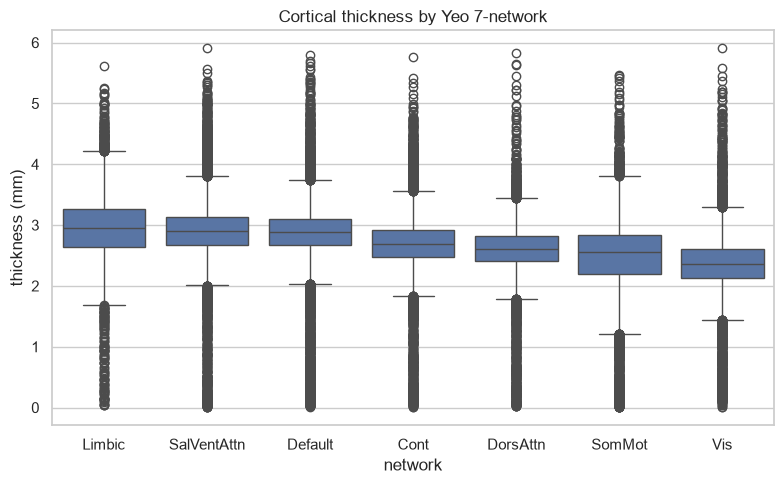

In [7]:
schaefer_net = schaefer.copy()
schaefer_net["network"] = schaefer_net["region"].str.extract(r"7Networks_[LR]H_([A-Za-z]+)_")

fig, ax = plt.subplots(figsize=(8, 5))
order = schaefer_net.groupby("network")["value"].mean().sort_values(ascending=False).index
sns.boxplot(data=schaefer_net, x="network", y="value", order=order, ax=ax)
ax.set_title("Cortical thickness by Yeo 7-network")
ax.set_ylabel("thickness (mm)")
plt.tight_layout()

## 6. Cross-atlas consistency

Per-session mean thickness should track closely between the custom Schaefer atlas and
CAT12's own DK40 — same underlying native thickness map, just different parcellations.
Not identical (different region boundaries), but strongly correlated is the real
sanity check.

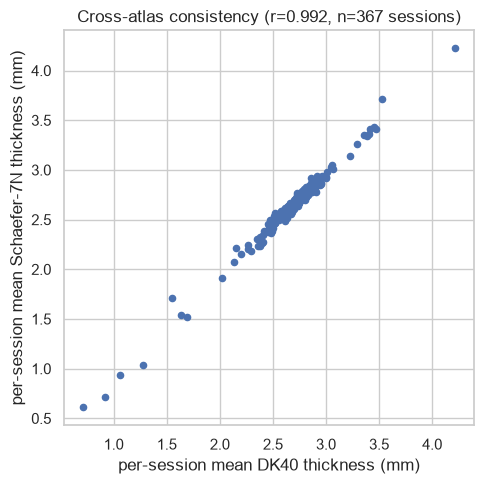

In [8]:
dk40_means = pd.read_sql('''
    select subject_key, session_id, avg(value) as dk40_mean
    from features where atlas = "surf_DK40" and metric = "thickness"
    group by subject_key, session_id
''', con)
schaefer_means = schaefer.groupby(["subject_key", "session_id"])["value"].mean().rename("schaefer_mean").reset_index()

cross = dk40_means.merge(schaefer_means, on=["subject_key", "session_id"])
corr = cross["dk40_mean"].corr(cross["schaefer_mean"])

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(cross["dk40_mean"], cross["schaefer_mean"], s=20)
ax.set_xlabel("per-session mean DK40 thickness (mm)")
ax.set_ylabel("per-session mean Schaefer-7N thickness (mm)")
ax.set_title(f"Cross-atlas consistency (r={corr:.3f}, n={len(cross)} sessions)")
plt.tight_layout()

## 7. Additional surface parameters — gyrification, sulcal depth, fractal dimension, area

Beyond cortical thickness, CAT12's `surfextract` module (`spm.tools.cat.stools.surfextract`,
wired into `container/cat12.def` as job 2, 2026-08-24 — see
`docs/cat12_container_spec.md` §4d for how the field names/values were confirmed against
CAT12's real public source, and the real bug found+fixed along the way where the first
attempt broke the whole batch load) computes four more per-vertex measures, resampled onto
the same custom Schaefer2018N400n7 grid as thickness above
(`bagpipe.app.surface_atlas.SURFACE_METRICS`):

- **Gyrification index (GI)** — local folding/cortical-complexity measure (absolute mean
  curvature of the central surface, smoothed); higher = more folded cortex.
- **Sulcal depth (SD)** — Euclidean/geodesic distance from a vertex to a reference (hull)
  surface; deeper sulci score higher.
- **Fractal dimension (FD)** — cortical-complexity measure via spherical harmonic
  reconstruction at increasing resolution; captures folding complexity that plain
  curvature/depth measures miss.
- **Area** — per-vertex surface area on the central surface, averaged per region — a
  cortical-surface-area analog to volumetric GM volume, but decoupled from thickness
  (surface area and thickness are known to have largely independent genetic/developmental
  drivers in the literature, which is the actual reason to include both rather than
  thickness alone).

**Not yet independently validated against CAT12's own ground truth** the way thickness was
in §1 above — CAT12 doesn't natively export these onto DK40/Destrieux in `catROIs_*.xml`
the way it does thickness, so there's no equivalent "CAT12's own number" to diff against.
The resampling method itself is the same code path already validated for thickness; treat
these four as validated-by-shared-machinery, not independently confirmed, until the
cohort has enough coverage for a literature-plausibility check (e.g. FD/GI ranges against
published values) below.


### 7a. Coverage per metric


In [9]:
extra_metrics = ["gyrification", "sulcal_depth", "fractal_dimension", "area"]
extra = pd.read_sql(f'''
    select subject_key, session_id, metric, region, value
    from features
    where atlas = "surf_Schaefer2018N400n7" and metric in ({','.join('?' * len(extra_metrics))})
''', con, params=extra_metrics)

coverage = extra.groupby("metric")["session_id"].nunique().reindex(extra_metrics).fillna(0).astype(int)
coverage["thickness"] = schaefer["session_id"].nunique()
print(coverage.rename("n_sessions"))


metric
gyrification         131
sulcal_depth         131
fractal_dimension    130
area                 131
thickness            368
Name: n_sessions, dtype: int64


### 7b. Distributions

One panel per metric — same all-regions/all-sessions histogram style as thickness's own
§3 above. Units/ranges differ by metric (GI is unitless mean-curvature-derived, SD in mm,
FD unitless ~2.0-3.0 for a folded cortical surface, area in mm²) so each gets its own axis,
not a shared one.


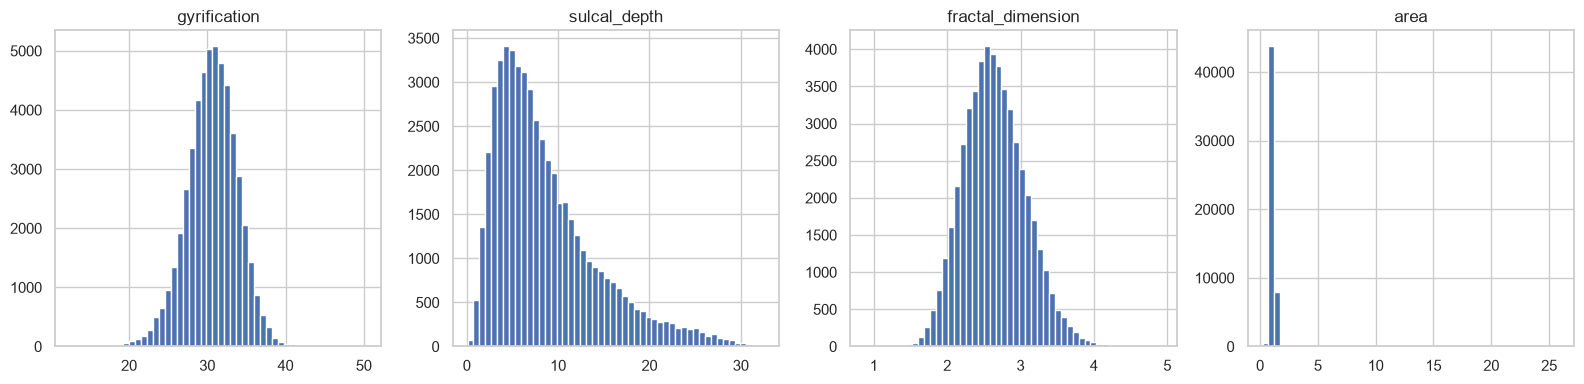

In [10]:
fig, axes = plt.subplots(1, len(extra_metrics), figsize=(4 * len(extra_metrics), 4))
for ax, metric in zip(axes, extra_metrics):
    extra.loc[extra["metric"] == metric, "value"].hist(bins=50, ax=ax)
    ax.set_title(metric)
plt.tight_layout()


### 7c. Network-level structure

Same Yeo 7-network grouping as thickness's §5 — worth checking each new metric shows
real between-network structure (not just noise) before trusting it as a model feature.


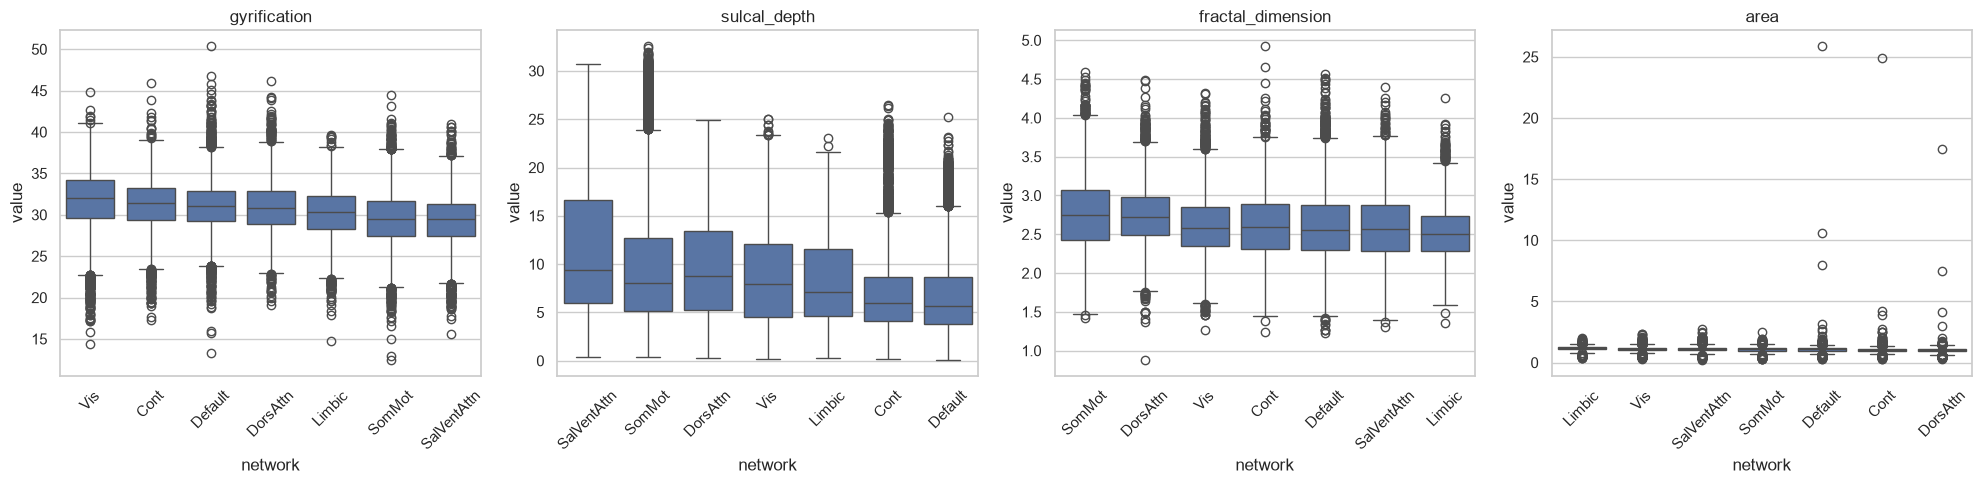

In [12]:
extra_net = extra.copy()
extra_net["network"] = extra_net["region"].str.extract(r"7Networks_[LR]H_([A-Za-z]+)_")

fig, axes = plt.subplots(1, len(extra_metrics), figsize=(5 * len(extra_metrics), 5), sharex=False)
for ax, metric in zip(axes, extra_metrics):
    sub = extra_net[extra_net["metric"] == metric]
    order = sub.groupby("network")["value"].mean().sort_values(ascending=False).index
    sns.boxplot(data=sub, x="network", y="value", order=order, ax=ax)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()


## 8. Modeling implication — why `atlases` filtering matters

`bagpipe.models.tabular.build_region_matrix` filters columns by `metric` alone — every
metric above (including thickness) also exists on `surf_DK40`/`surf_Destrieux`
(`bagpipe.app.cat12_parse.SURFACE_METRIC_TAGS`, read straight from CAT12's own
`catROIs_*.xml`), not just this notebook's custom Schaefer atlas. A `features.metrics`
config list with no atlas restriction pulls all three atlases' columns into one flat
matrix, which is exactly what caused a real underdetermined-fit r² collapse
(0.76→0.59) noted in `CLAUDE.md`'s 2026-08-24 CAT26-cohort-modeling entry when only
`thickness` was fused this way (3 atlases × ~400-2400 regions vs. a couple hundred
samples). `build_region_matrix` gained a `features.atlases` filter (2026-08-24) for
exactly this — `config/models/stacked_v26_surface.yaml` restricts to
`[Schaefer2018N400n7Tian2020S2, surf_Schaefer2018N400n7]` so every surface metric here
fuses onto the *same* parcellation as the volume features, not three different ones.
